#### Survival inference with pymc

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from survivalpredict.estimators import CoxProportionalHazard
from survivalpredict.datasets import load_iranian_telecom_churn

az.style.use("arviz-darkgrid")

In cases of making inferences or predictions on a trained model, it might be valuable to gauge uncertainty. PyMC is a Bayesian/‘Markov chain Monte Carlo’ framework. Simply put, PyMC allows us to build models that can capture the uncertainty and possible variability of our model, given the observed data and model assumptions. There is much literature on PyMC/MCMC; we will assume some familiarity with the topic.

Curretly surivivalpredict supports generating equivalent PyMC models for two of its estimator classes. The ‘CoxProportionalHazard‘s ‘get_pymc_model‘ method will return an equivalent pymc model. Models with either ‘efron’ or ‘breslow’ ties, stratification, L2 regularization, and left-censorship are all supported. The ‘ParametricDiscreteTimePH’ actually uses PyMC under the hood, calling the ‘get_pymc_model‘ will return the underlying pymc model.

In [2]:
#loading some sample data
iranian_telecom_churn_dict = load_iranian_telecom_churn()
X = iranian_telecom_churn_dict['X']
#in this case is important to scale our data
X = StandardScaler().fit_transform(X)
times = iranian_telecom_churn_dict['times'].astype(np.int64)
events = iranian_telecom_churn_dict['events'].astype(np.bool_)
column_names = iranian_telecom_churn_dict['column_names']

In [3]:
cox = CoxProportionalHazard(ties='efron').fit(X,times,events)
print(cox.coef_)

[ 0.50777218  0.48238747 -0.44392135  0.42167482 -2.31404596 -2.99677386
 -0.37073225 -0.417258    0.26621988 -0.03414636  0.30532322  1.86236737]


The'CoxProportionalHazard' class comes with a pymc model generator that builds pymc models that are equivalent to the survivalpredict model. It should be noted that adding time_start/'left-censorship' will drastically reduce the samples per second of the pymc class, as it triggers more computation. Stratification will also somewhat slow down sampling.


When calling 'get_pymc_model', if the 'empirical_bayes' argument is set to True, and our estimator class has already been trained, the initial values of our PyMC model coefficients will be the coefficients trained by our estimator class.

In [4]:
#Getting our pymc model, setting empirical_bayes to False as part of our demonstration.
pymc_model = cox.get_pymc_model(X, times, events,labes_names=column_names,empirical_bayes=False)

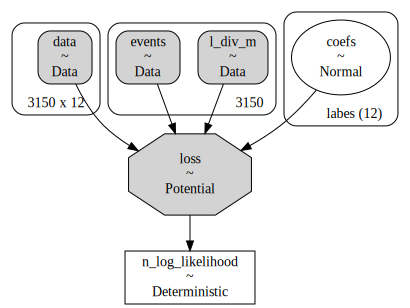

In [5]:
pm.model_to_graphviz(pymc_model)

A quick demonstration to show that this PyMC model is equivalent to our survivalpredict model would be to generate the ‘maximum likelihood estimation’/’maximum a posteriori’ estimates and compare them to our coefficients. 

In [6]:
with pymc_model:
    mle = pm.find_MAP()

Output()

In [7]:
mle

{'coefs': array([ 0.50733508,  0.48238074, -0.44546389,  0.43406345, -2.31074651,
        -2.9503162 , -0.37137833, -0.4172489 ,  0.26588864, -0.03518892,
         0.30293834,  1.81416004]),
 'n_log_likelihood': array(3052.59817273)}

In [8]:
print('coefs: ',cox.coef_)
print('n_log_likelihood: ',cox.n_log_likelihood)
#looks pretty close to me

coefs:  [ 0.50777218  0.48238747 -0.44392135  0.42167482 -2.31404596 -2.99677386
 -0.37073225 -0.417258    0.26621988 -0.03414636  0.30532322  1.86236737]
n_log_likelihood:  3052.597200555113


In [9]:
#generating the trace/sampling
#this might take a bit, it can be faster with a gpu.
with pymc_model:
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coefs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.
There were 10 divergences after tuning. Increase `target_accept` or reparameterize.


In [10]:
az.summary(idata)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
coefs[call_failure],0.506,0.078,0.38,0.63,2518,2616,1.00,0.0016,0.0011
coefs[complains],0.4828,0.0293,0.44,0.53,3773,2332,1.00,0.00048,0.00033
coefs[charge_amount],-0.452,0.141,-0.68,-0.23,2351,2165,1.00,0.0029,0.002
coefs[seconds_of_use],0.39,0.47,-0.38,1.2,1719,1985,1.00,0.011,0.008
coefs[frequency_of_use],-2.3,0.343,-2.9,-1.7,2493,2603,1.00,0.0069,0.0048
coefs[frequency_of_sms],-3.05,1.06,-4.7,-1.4,1866,1926,1.00,0.024,0.017
coefs[distinct_called_numbers],-0.366,0.135,-0.58,-0.15,3080,2632,1.00,0.0024,0.0017
coefs[age_group],-0.412,0.173,-0.69,-0.13,2672,2391,1.01,0.0033,0.0023
coefs[tariff_plan],0.24,0.122,0.037,0.42,3667,2280,1.00,0.0021,0.0015
coefs[status],-0.032,0.067,-0.14,0.079,2526,2511,1.00,0.0013,0.00095


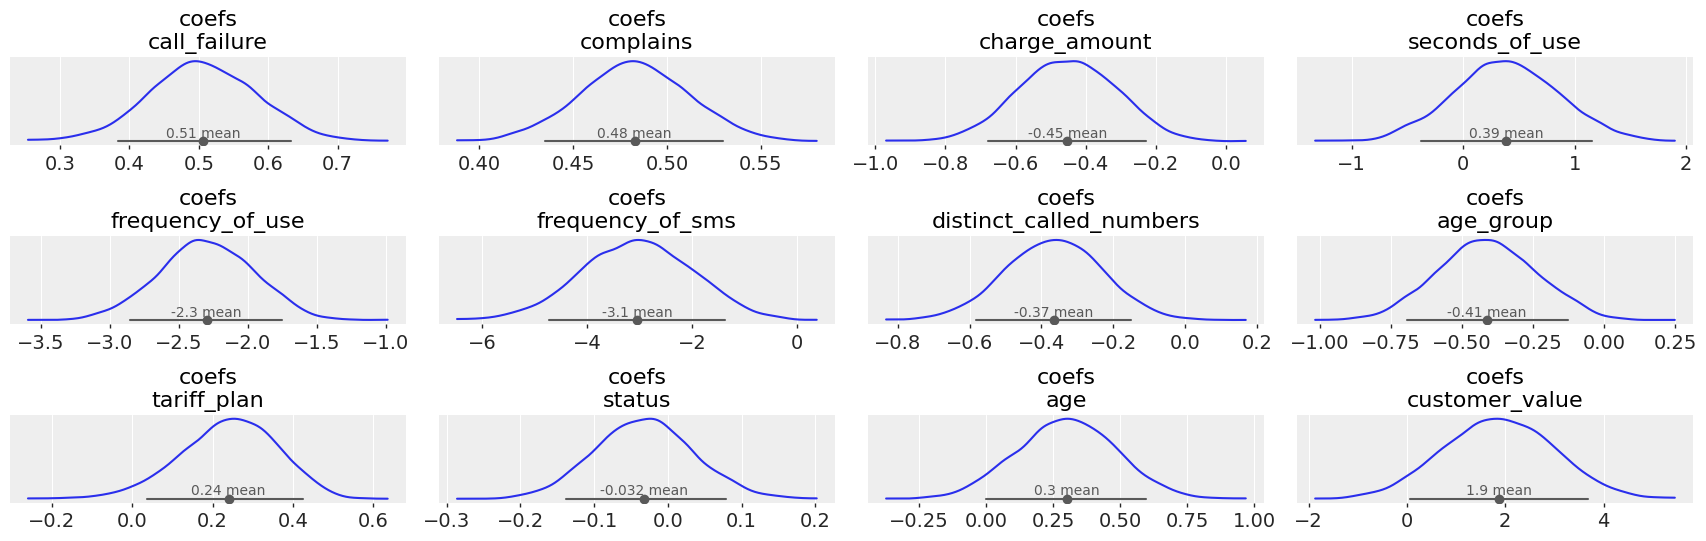

In [11]:
#obtaining our 'highest density intervals'/credible intervals for the probable effect of different variables.
az.plot_dist(idata,var_names='coefs')
plt.tight_layout()

It is common for MCMC practitioners to generate ‘Posterior Probability Statements’ by asking binary questions across posterior traces and obtaining their mean as a gauge of certainty. Below is simply a comparison of the effects of parameters. There are a lot of good resources on more advanced bayesian inference techniques on MCMC traces.

In [12]:
coef1 = 'complains'
coef2 = 'seconds_of_use'

baysian_p_value = (idata['posterior']['coefs'].sel(labes=coef1) > idata['posterior']['coefs'].sel(labes=coef2)).mean().values

print(f'the baysian p value that {coef1} have more effect on {coef2} is :{baysian_p_value}')
#we should not be very certain with such middling number

the baysian p value that complains have more effect on seconds_of_use is :0.58675


Below is a  taste of what is possible with PyMC traces. We can take a look at possible coefficients and build a range of possible predictions for our survival curves. It should be noted that our solution would look different for doing the same thing with a stratified mode. Some of is here may be packaged into tooling within survivalpredict in the future.

In [13]:
#poping out an internal function, ;)
from survivalpredict._base_hazard import _get_breslow_base_hazard

In [14]:
#turning coefs from the pymc traces into breslow base hazards
coefs_from_trace = idata.posterior.coefs.values.reshape(-1,X.shape[1])
risk_per_coef_per_row = np.exp(np.dot(coefs_from_trace,X.T))
max_time = np.max(times)
hazard_per_coef = np.apply_along_axis(lambda risk_array : _get_breslow_base_hazard(risk_array,times,events,max_time),1,risk_per_coef_per_row)
base_survival_per_coef = np.exp(- hazard_per_coef.cumsum(axis=1))

In [15]:
#the row we wants to build prediction intervals for. This row can also be something out of sample.
row_to_predict = X[17]

#building the survival_curves
predict_risk = np.exp(np.dot(coefs_from_trace,row_to_predict.T))
survival_curve_per_coef = base_survival_per_coef**predict_risk[:,None]

In [16]:
means = np.quantile(survival_curve_per_coef, .5,axis=0)
#we are looking at the 5% and 95% intervals
quantiles = np.quantile(survival_curve_per_coef, [0.05,0.95],axis=0)

Text(0, 0.5, 'Probability of Survival')

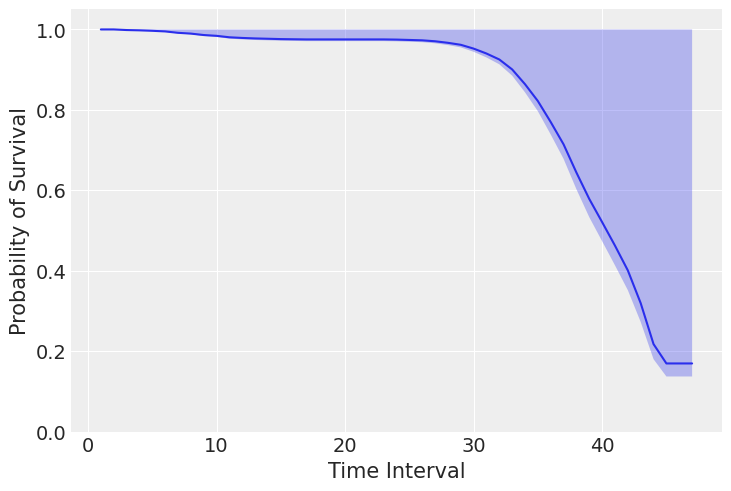

In [17]:
plt.plot(np.arange(1,len(means)+1),means)
plt.fill_between(np.arange(1,len(means)+1),quantiles[0,:],quantiles[1,0],alpha=0.3)
ax = plt.gca()
ax.set_ylim(0.0,1.05)
plt.xlabel("Time Interval")
plt.ylabel("Probability of Survival")
